In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Load data
X_train = np.load('../data/processed/X_train.npy')
y_train = np.load('../data/processed/y_train.npy')

X_val = np.load("../data/processed/X_val.npy")
y_val = np.load("../data/processed/y_val.npy")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)


X_train shape: (69600, 128, 128, 3)
y_train shape: (69600, 29)
X_val shape: (17400, 128, 128, 3)
y_val shape: (17400, 29)


In [3]:
#check data range
print("Min pixel value:", X_train.min())
print("Max pixel value:", X_train.max())

Min pixel value: -1.0
Max pixel value: 1.0


In [4]:
#check label format
print("Unique labels:", np.unique(y_train))
print("Number of classes:", len(np.unique(y_train)))

Unique labels: [0. 1.]
Number of classes: 2


In [5]:
print("y_train sample:", y_train[0])

y_train sample: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0.]


In [6]:
y_train = np.argmax(y_train, axis=1)
y_val = np.argmax(y_val, axis=1)

In [7]:
print("Unique labels:", np.unique(y_train))
print("Number of classes:", len(np.unique(y_train)))

Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28]
Number of classes: 29


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

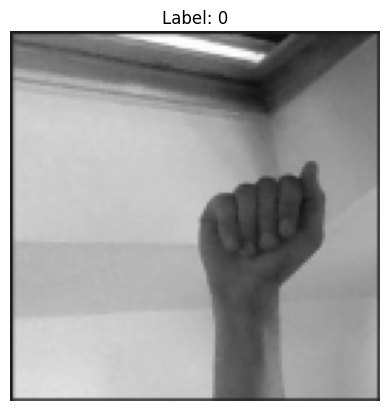

In [8]:
plt.imshow((X_train[0] + 1) / 2)  # convert back to [0,1] for display
plt.title(f"Label: {y_train[0]}")
plt.axis("off")

In [9]:
import torch

X_train = torch.tensor(X_train).permute(0, 3, 1, 2).float()
X_val = torch.tensor(X_val).permute(0, 3, 1, 2).float()

y_train = torch.tensor(y_train).long()
y_val = torch.tensor(y_val).long()

print("X_train shape:", X_train.shape)

X_train shape: torch.Size([69600, 3, 128, 128])


In [10]:
device = torch.device("cpu")
print("Using device:", device)

Using device: cpu


### Load MobileNetV2

In [11]:
from torchvision import models
import torch.nn as nn

model = models.mobilenet_v2(pretrained=True)

c:\Users\Vidusahan Perera\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Vidusahan Perera\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Modify Final Layer

In [12]:
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 29)

### Freeze Feature Extractor

In [13]:
for param in model.features.parameters():
    param.requires_grad = False

### Move Model to Device

In [14]:
model = model.to(device)

### Verify Model

In [15]:
print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=29, bias=True)
)


### Check Trainable Parameters

In [16]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print("Trainable params:", trainable)
print("Total params:", total)

Trainable params: 37149
Total params: 2261021


### Create DataLoader

In [17]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

### Loss Function

In [18]:
criterion = nn.CrossEntropyLoss()

### Optimizer

In [19]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.001)

### Training Loop

In [20]:
import time

num_epochs = 10

# Early stopping settings
patience = 3
counter = 0
best_val_loss = float('inf')
best_val_acc = 0

for epoch in range(num_epochs):
    start_time = time.time()

    # ================= TRAIN =================
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total
    avg_train_loss = train_loss / len(train_loader)

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    avg_val_loss = val_loss / len(val_loader)

    # ================= LOGGING =================
    duration = time.time() - start_time

    print(f"\nEpoch {epoch+1} Summary:")
    print(f" Train: Loss={avg_train_loss:.4f}, Acc={train_acc*100:.2f}%")
    print(f" Val:   Loss={avg_val_loss:.4f}, Acc={val_acc*100:.2f}%")
    print(f" Time:  {duration:.1f}s")

    # ================= SAVE BEST MODEL (ACCURACY) =================
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        print(f" >> New best validation accuracy: {val_acc*100:.2f}%")

    # ================= EARLY STOPPING (LOSS) =================
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        print(" >> Validation loss improved, saving model")

        torch.save(model.state_dict(), "best_model.pth")

    else:
        counter += 1
        print(f" >> No improvement ({counter}/{patience})")

        if counter >= patience:
            print("\n Early stopping triggered!")
            break

    print("-" * 60)

c:\Users\Vidusahan Perera\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\cuda\__init__.py:382: UserWarning: Found GPU0 NVIDIA GeForce RTX 5050 Laptop GPU which is of compute capability (CC) 12.0.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 5.0 which supports hardware CC >=5.0,<6.0 except {5.3}
- 6.0 which supports hardware CC >=6.0,<7.0 except {6.2}
- 6.1 which supports hardware CC >=6.1,<7.0 except {6.2}
- 7.0 which supports hardware CC >=7.0,<8.0 except {7.2}
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
Please follow the instructions at https://pytorch.org/get-started/locally/ to install a PyTorch release that supports one of these CUDA versions: 12.8, 13.0
  _warn_unsupported_code(d, device_cc, code_ccs)
c:\Users\Vidusahan Perera\AppData\Local\Progr


Epoch 1 Summary:
 Train: Loss=0.7218, Acc=79.63%
 Val:   Loss=0.2826, Acc=91.81%
 Time:  442.0s
 >> New best validation accuracy: 91.81%
 >> Validation loss improved, saving model
------------------------------------------------------------

Epoch 2 Summary:
 Train: Loss=0.4053, Acc=87.03%
 Val:   Loss=0.2036, Acc=93.97%
 Time:  451.8s
 >> New best validation accuracy: 93.97%
 >> Validation loss improved, saving model
------------------------------------------------------------

Epoch 3 Summary:
 Train: Loss=0.3661, Acc=88.03%
 Val:   Loss=0.1686, Acc=94.76%
 Time:  398.2s
 >> New best validation accuracy: 94.76%
 >> Validation loss improved, saving model
------------------------------------------------------------

Epoch 4 Summary:
 Train: Loss=0.3458, Acc=88.63%
 Val:   Loss=0.1543, Acc=95.20%
 Time:  399.7s
 >> New best validation accuracy: 95.20%
 >> Validation loss improved, saving model
------------------------------------------------------------

Epoch 5 Summary:
 Train: Loss=0